<a href="https://www.kaggle.com/code/omborse771924/netflix-movies-and-series-analysis-99-9-accuracy?scriptVersionId=339337940" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/debayank2024/netflix-movies-and-series/netflix_titles.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/debayank2024/netflix-movies-and-series/netflix_titles.csv')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [6]:
df.describe

<bound method NDFrame.describe of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail M

In [7]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
# Create a copy
data = df.copy()

# ==========================
# Fill Text Columns
# ==========================

text_cols = [
    "director",
    "cast",
    "country"
]

for col in text_cols:
    data[col] = data[col].fillna("Unknown")

# ==========================
# Fill Mode Values
# ==========================

mode_cols = [
    "date_added",
    "rating",
    "duration"
]

for col in mode_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# ==========================
# Verify Missing Values
# ==========================

print("Remaining Missing Values:\n")
print(data.isnull().sum())

Remaining Missing Values:

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## EDA

Dataset Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  M

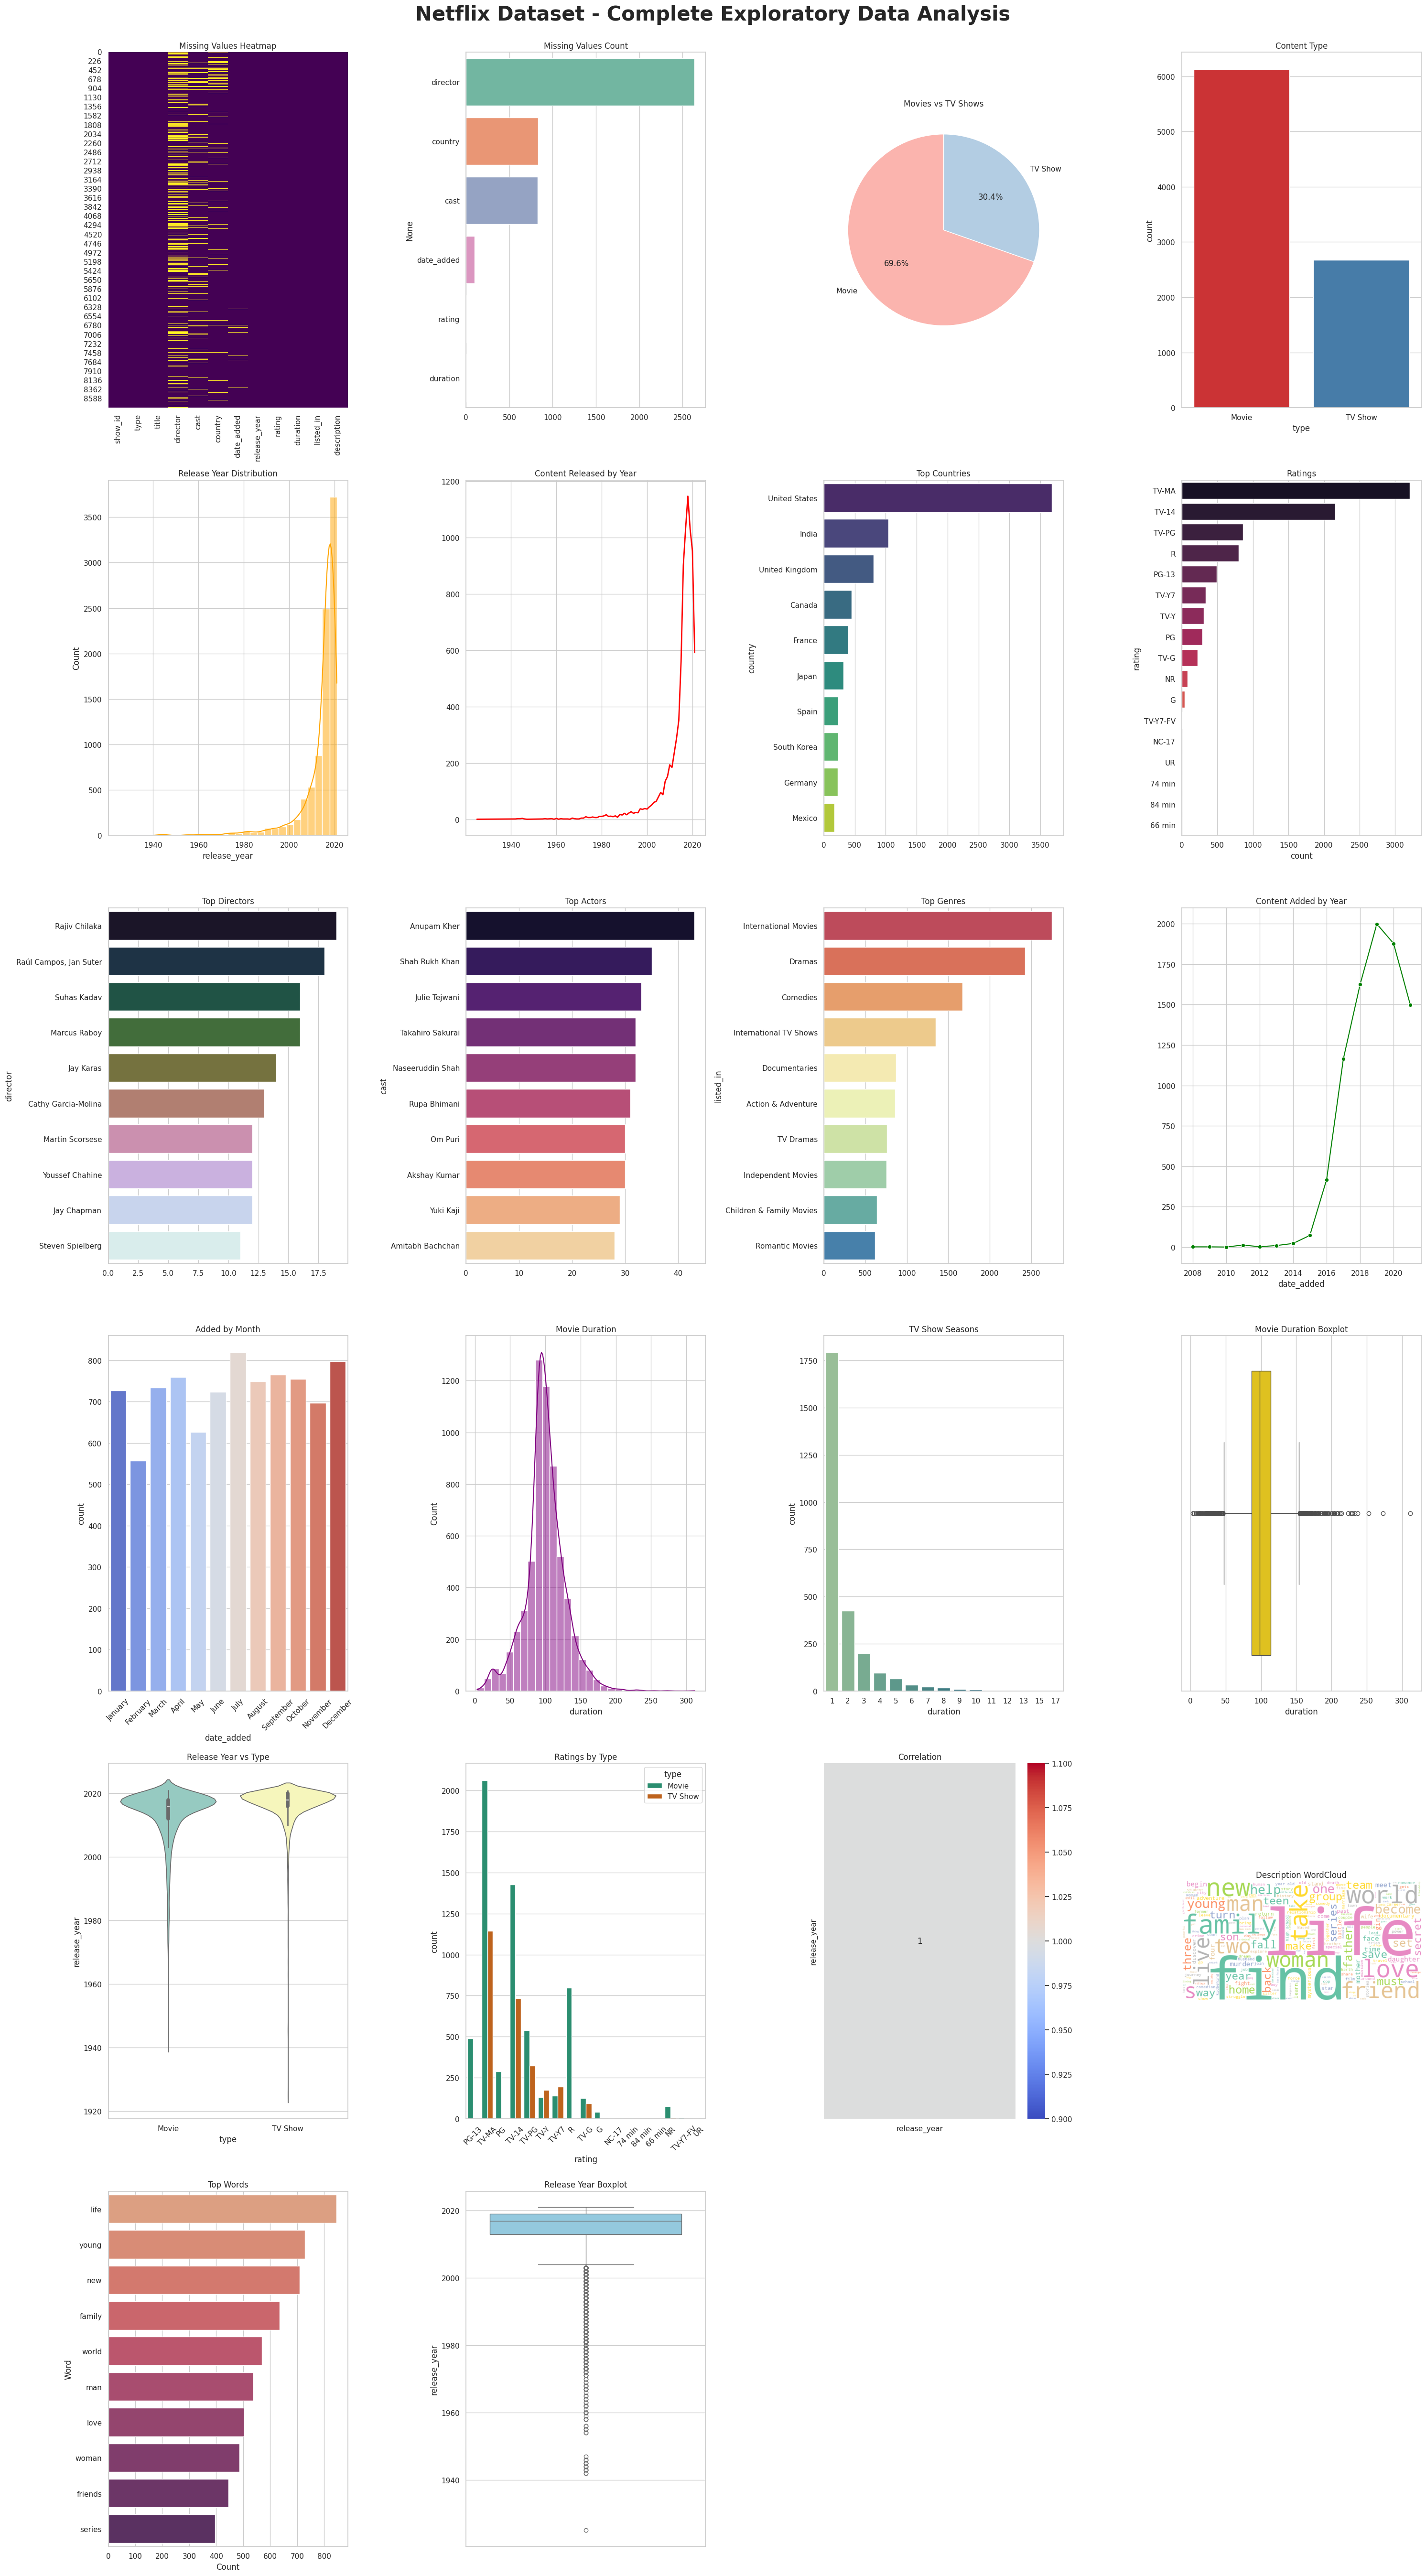

In [13]:
# ==========================
# NETFLIX DATASET - COMPLETE EDA VISUALIZATION
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# --------------------------
# Basic Settings
# --------------------------
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

print("="*60)
print("Dataset Shape:", df.shape)
print("="*60)
print(df.info())
print("="*60)
print(df.describe(include="all"))

# Convert Date
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# ==========================================================
# Create Subplots
# ==========================================================
fig = plt.figure(figsize=(30,55))
fig.suptitle("Netflix Dataset - Complete Exploratory Data Analysis",
             fontsize=30,
             fontweight='bold')

plot = 1

# ==========================================================
# 1 Missing Values
# ==========================================================
plt.subplot(6,4,plot)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plot += 1

# ==========================================================
# 2 Missing Value Count
# ==========================================================
plt.subplot(6,4,plot)
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="Set2"
)
plt.title("Missing Values Count")
plot += 1

# ==========================================================
# 3 Movies vs TV Shows
# ==========================================================
plt.subplot(6,4,plot)

df["type"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=sns.color_palette("Pastel1"),
    startangle=90
)

plt.ylabel("")
plt.title("Movies vs TV Shows")
plot += 1

# ==========================================================
# 4 Type Count
# ==========================================================
plt.subplot(6,4,plot)
sns.countplot(
    data=df,
    x="type",
    palette="Set1"
)
plt.title("Content Type")
plot += 1

# ==========================================================
# 5 Release Year Distribution
# ==========================================================
plt.subplot(6,4,plot)
sns.histplot(
    df["release_year"],
    bins=30,
    kde=True,
    color="orange"
)
plt.title("Release Year Distribution")
plot += 1

# ==========================================================
# 6 Release Trend
# ==========================================================
plt.subplot(6,4,plot)

year = df["release_year"].value_counts().sort_index()

plt.plot(
    year.index,
    year.values,
    color="red",
    linewidth=2
)

plt.title("Content Released by Year")
plot += 1

# ==========================================================
# 7 Top Countries
# ==========================================================
plt.subplot(6,4,plot)

country = df["country"].dropna().str.split(", ").explode()

top_country = country.value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    palette="viridis"
)

plt.title("Top Countries")
plot += 1

# ==========================================================
# 8 Ratings
# ==========================================================
plt.subplot(6,4,plot)

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index,
    palette="rocket"
)

plt.title("Ratings")
plot += 1

# ==========================================================
# 9 Directors
# ==========================================================
plt.subplot(6,4,plot)

director = df["director"].dropna().value_counts().head(10)

sns.barplot(
    x=director.values,
    y=director.index,
    palette="cubehelix"
)

plt.title("Top Directors")
plot += 1

# ==========================================================
# 10 Actors
# ==========================================================
plt.subplot(6,4,plot)

cast = df["cast"].dropna().str.split(", ").explode()

top_cast = cast.value_counts().head(10)

sns.barplot(
    x=top_cast.values,
    y=top_cast.index,
    palette="magma"
)

plt.title("Top Actors")
plot += 1

# ==========================================================
# 11 Genres
# ==========================================================
plt.subplot(6,4,plot)

genre = df["listed_in"].dropna().str.split(", ").explode()

top_genre = genre.value_counts().head(10)

sns.barplot(
    x=top_genre.values,
    y=top_genre.index,
    palette="Spectral"
)

plt.title("Top Genres")
plot += 1

# ==========================================================
# 12 Added Year
# ==========================================================
plt.subplot(6,4,plot)

added = df["date_added"].dt.year.value_counts().sort_index()

sns.lineplot(
    x=added.index,
    y=added.values,
    marker="o",
    color="green"
)

plt.title("Content Added by Year")
plot += 1

# ==========================================================
# 13 Added Month
# ==========================================================
plt.subplot(6,4,plot)

month = df["date_added"].dt.month_name()

order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

sns.countplot(
    x=month,
    order=order,
    palette="coolwarm"
)

plt.xticks(rotation=45)
plt.title("Added by Month")
plot += 1

# ==========================================================
# 14 Movie Duration
# ==========================================================
plt.subplot(6,4,plot)

movies = df[df["type"]=="Movie"].copy()

movies["duration"] = (
    movies["duration"]
    .str.replace(" min","", regex=False)
)

movies["duration"] = pd.to_numeric(
    movies["duration"],
    errors="coerce"
)

sns.histplot(
    movies["duration"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Movie Duration")
plot += 1

# ==========================================================
# 15 TV Seasons
# ==========================================================
plt.subplot(6,4,plot)

tv = df[df["type"]=="TV Show"].copy()

tv["duration"] = (
    tv["duration"]
    .str.replace(" Seasons","", regex=False)
    .str.replace(" Season","", regex=False)
)

tv["duration"] = pd.to_numeric(
    tv["duration"],
    errors="coerce"
)

sns.countplot(
    x=tv["duration"],
    palette="crest"
)

plt.title("TV Show Seasons")
plot += 1

# ==========================================================
# 16 Boxplot
# ==========================================================
plt.subplot(6,4,plot)

sns.boxplot(
    x=movies["duration"],
    color="gold"
)

plt.title("Movie Duration Boxplot")
plot += 1

# ==========================================================
# 17 Violin Plot
# ==========================================================
plt.subplot(6,4,plot)

sns.violinplot(
    data=df,
    x="type",
    y="release_year",
    palette="Set3"
)

plt.title("Release Year vs Type")
plot += 1

# ==========================================================
# 18 Rating by Type
# ==========================================================
plt.subplot(6,4,plot)

sns.countplot(
    data=df,
    x="rating",
    hue="type",
    palette="Dark2"
)

plt.xticks(rotation=45)
plt.title("Ratings by Type")
plot += 1

# ==========================================================
# 19 Correlation Heatmap
# ==========================================================
plt.subplot(6,4,plot)

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation")
plot += 1

# ==========================================================
# 20 Word Cloud
# ==========================================================
plt.subplot(6,4,plot)

text = " ".join(df["description"].dropna())

wc = WordCloud(
    width=600,
    height=300,
    background_color="white",
    colormap="Set2"
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Description WordCloud")
plot += 1

# ==========================================================
# 21 Top Words
# ==========================================================
plt.subplot(6,4,plot)

cv = CountVectorizer(stop_words="english")

matrix = cv.fit_transform(df["description"].fillna(""))

count = np.asarray(matrix.sum(axis=0)).ravel()

words = pd.DataFrame({
    "Word": cv.get_feature_names_out(),
    "Count": count
})

top = words.sort_values(
    by="Count",
    ascending=False
).head(10)

sns.barplot(
    x="Count",
    y="Word",
    data=top,
    palette="flare"
)

plt.title("Top Words")
plot += 1

# ==========================================================
# 22 Release Year Boxplot
# ==========================================================
plt.subplot(6,4,plot)

sns.boxplot(
    y=df["release_year"],
    color="skyblue"
)

plt.title("Release Year Boxplot")
plot += 1

# ==========================================================
# Layout
# ==========================================================
plt.tight_layout(rect=[0,0,1,0.98])
plt.show()

## Features Engineering

Logistic Regression

Accuracy : 0.996594778660613
Precision: 0.996611349080756
Recall   : 0.996594778660613
F1 Score : 0.9965893301815765
ROC AUC  : 0.9999984766431309

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      0.99      0.99       535

    accuracy                           1.00      1762
   macro avg       1.00      0.99      1.00      1762
weighted avg       1.00      1.00      1.00      1762



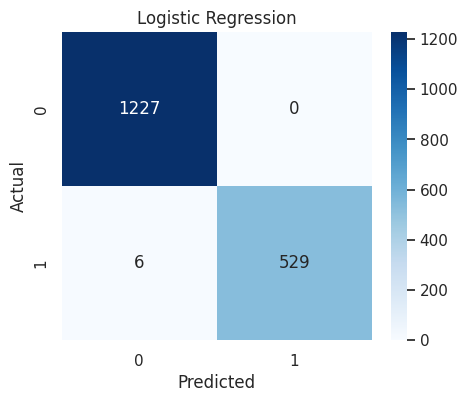

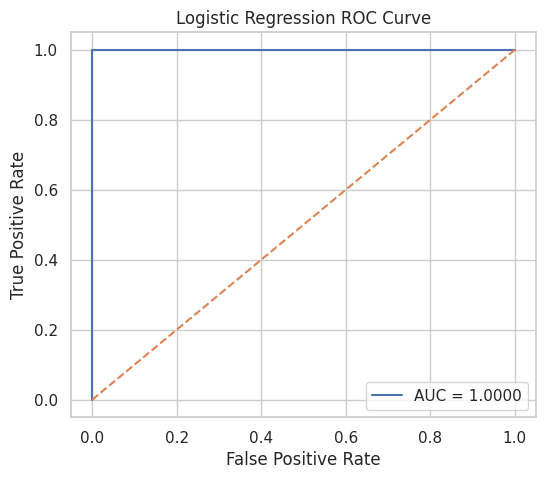

Decision Tree

Accuracy : 0.9875141884222475
Precision: 0.9877341146469958
Recall   : 0.9875141884222475
F1 Score : 0.9874386051401965
ROC AUC  : 0.9794392523364486

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1227
           1       1.00      0.96      0.98       535

    accuracy                           0.99      1762
   macro avg       0.99      0.98      0.99      1762
weighted avg       0.99      0.99      0.99      1762



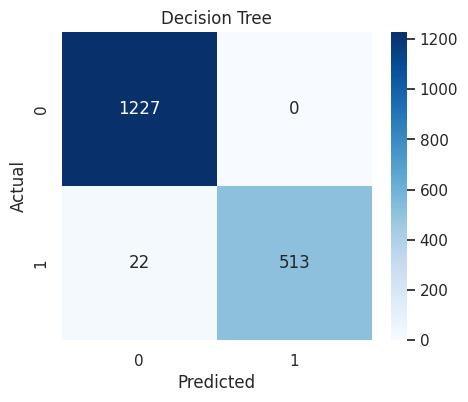

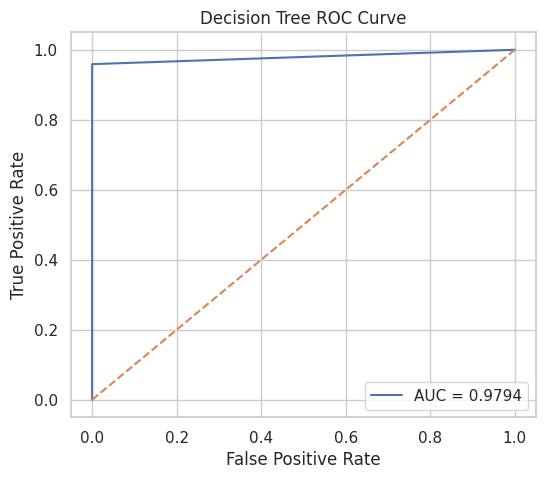

Random Forest

Accuracy : 0.9994324631101021
Precision: 0.9994329252736932
Recall   : 0.9994324631101021
F1 Score : 0.999432313245823
ROC AUC  : 0.9999984766431308

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      1.00      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



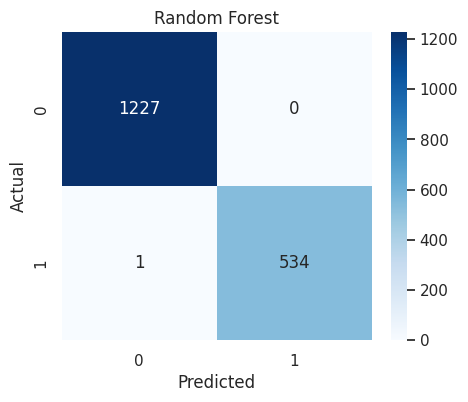

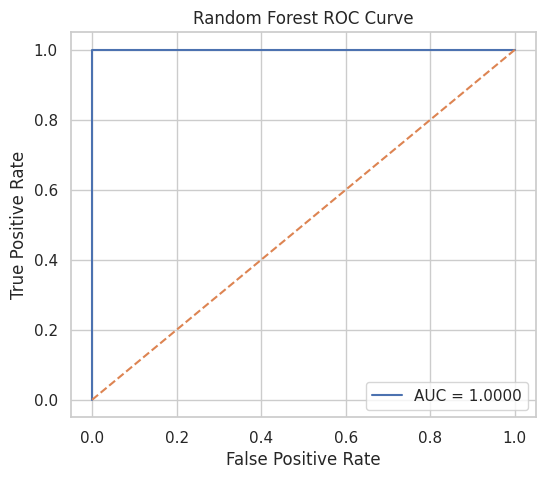

Gradient Boosting

Accuracy : 0.9886492622020431
Precision: 0.9888313109237424
Recall   : 0.9886492622020431
F1 Score : 0.988587040041577
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1227
           1       1.00      0.96      0.98       535

    accuracy                           0.99      1762
   macro avg       0.99      0.98      0.99      1762
weighted avg       0.99      0.99      0.99      1762



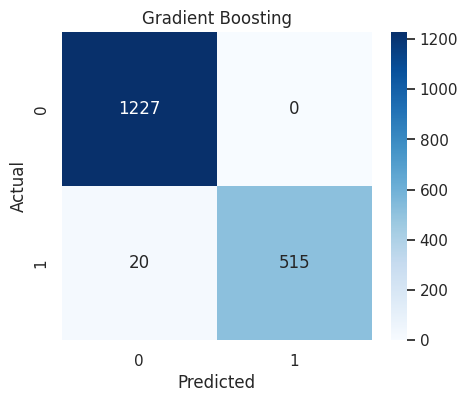

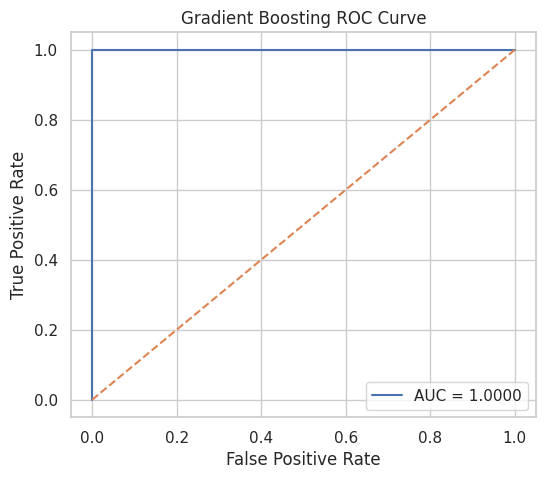

Extra Trees

Accuracy : 0.9977298524404086
Precision: 0.9977372290368655
Recall   : 0.9977298524404086
F1 Score : 0.9977274404019121
ROC AUC  : 0.9999969532862617

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1227
           1       1.00      0.99      1.00       535

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



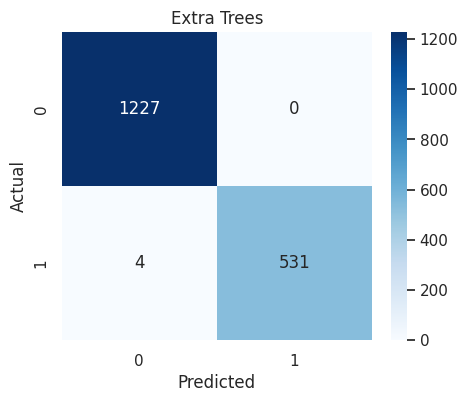

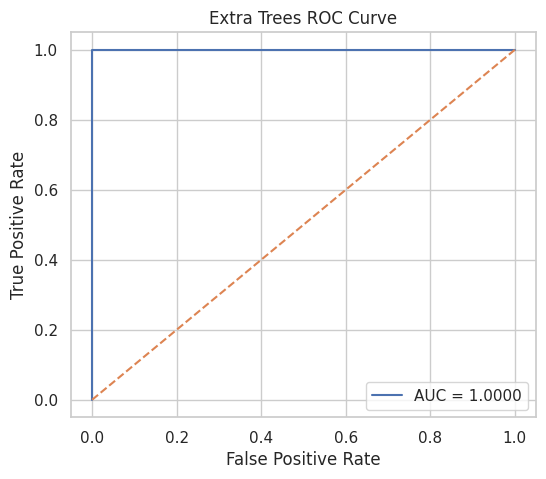

Naive Bayes

Accuracy : 0.9795686719636776
Precision: 0.9801510376084185
Recall   : 0.9795686719636776
F1 Score : 0.9793606972232554
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1227
           1       1.00      0.93      0.97       535

    accuracy                           0.98      1762
   macro avg       0.99      0.97      0.98      1762
weighted avg       0.98      0.98      0.98      1762



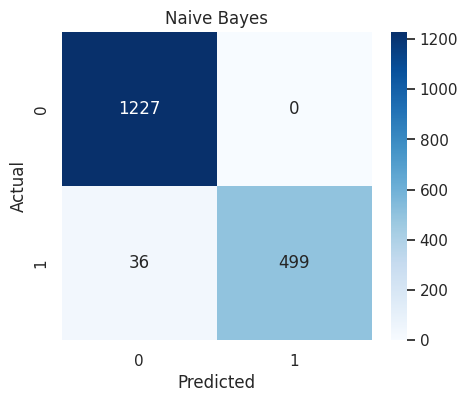

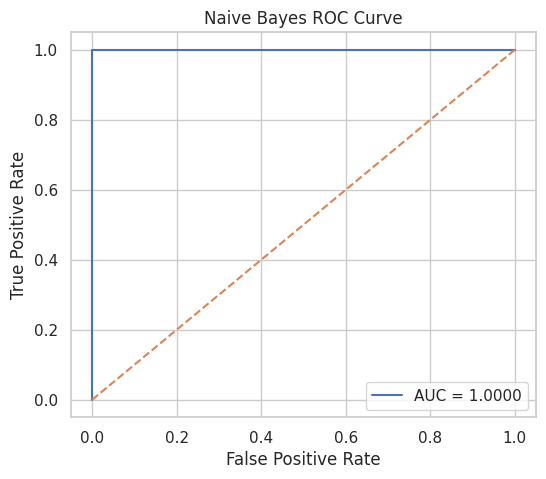

KNN

Accuracy : 0.7440408626560726
Precision: 0.7663639803253879
Recall   : 0.7440408626560726
F1 Score : 0.683135089970604
ROC AUC  : 0.9246540075710836

Classification Report

              precision    recall  f1-score   support

           0       0.74      0.98      0.84      1227
           1       0.83      0.20      0.32       535

    accuracy                           0.74      1762
   macro avg       0.79      0.59      0.58      1762
weighted avg       0.77      0.74      0.68      1762



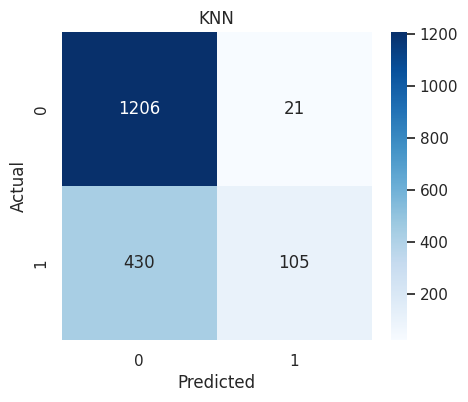

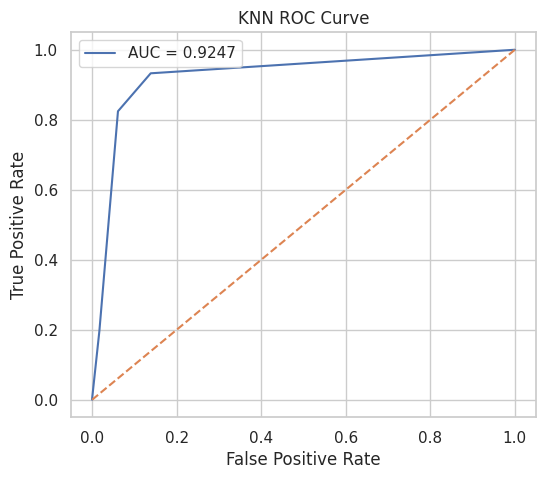

Support Vector Machine

Accuracy : 0.9290578887627696
Precision: 0.9326883631647833
Recall   : 0.9290578887627696
F1 Score : 0.9299489528086096
ROC AUC  : 0.9740694193725293

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1227
           1       0.85      0.93      0.89       535

    accuracy                           0.93      1762
   macro avg       0.91      0.93      0.92      1762
weighted avg       0.93      0.93      0.93      1762



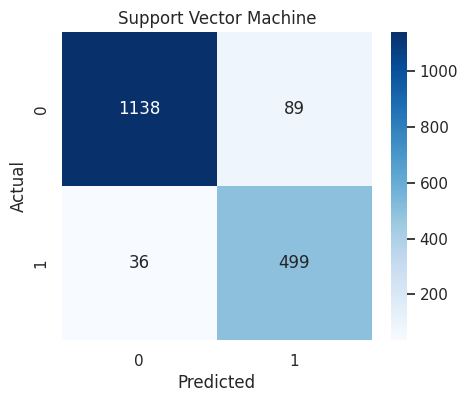

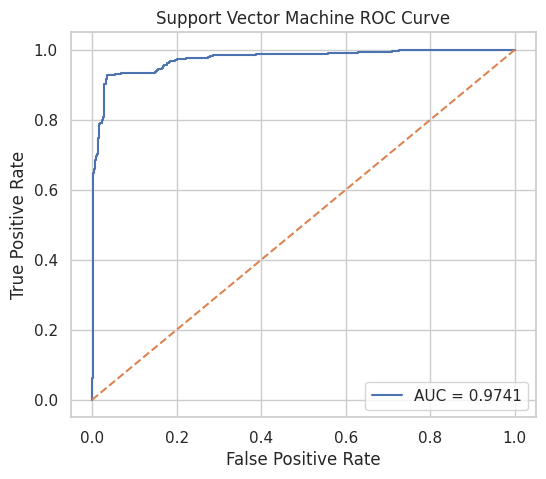


Model Comparison

                    Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
2           Random Forest  0.999432   0.999433  0.999432  0.999432  0.999998
4             Extra Trees  0.997730   0.997737  0.997730  0.997727  0.999997
0     Logistic Regression  0.996595   0.996611  0.996595  0.996589  0.999998
3       Gradient Boosting  0.988649   0.988831  0.988649  0.988587  1.000000
1           Decision Tree  0.987514   0.987734  0.987514  0.987439  0.979439
5             Naive Bayes  0.979569   0.980151  0.979569  0.979361  1.000000
7  Support Vector Machine  0.929058   0.932688  0.929058  0.929949  0.974069
6                     KNN  0.744041   0.766364  0.744041  0.683135  0.924654


In [14]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


# ===============================
# DROP DUPLICATES
# ===============================
df = df.drop_duplicates()

# ===============================
# HANDLE MISSING VALUES
# ===============================

text_columns = [
    'director',
    'cast',
    'country',
    'rating',
    'duration'
]

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])

# ===============================
# FEATURE ENGINEERING
# ===============================

# Date Features
df["date_added"] = pd.to_datetime(df["date_added"])

df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month

# Movie Duration
df["duration_num"] = (
    df["duration"]
    .str.extract("(\d+)")
    .fillna(0)
    .astype(int)
)

# Number of Genres
df["genre_count"] = df["listed_in"].apply(lambda x: len(str(x).split(",")))

# Number of Cast Members
df["cast_count"] = df["cast"].apply(lambda x: len(str(x).split(",")))

# Description Length
df["description_length"] = df["description"].apply(len)

# ===============================
# SELECT FEATURES
# ===============================

features = [
    'title',
    'director',
    'cast',
    'country',
    'release_year',
    'rating',
    'duration_num',
    'listed_in',
    'description',
    'added_year',
    'added_month',
    'genre_count',
    'cast_count',
    'description_length'
]

X = df[features]

y = df["type"]

# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ===============================
# LABEL ENCODING
# (NO DATA LEAKAGE)
# ===============================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

categorical_columns = [
    'title',
    'director',
    'cast',
    'country',
    'rating',
    'listed_in',
    'description'
]

encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    mapping = dict(zip(le.classes_,
                       le.transform(le.classes_)))

    X_test[col] = X_test[col].astype(str).map(mapping)

    X_test[col] = X_test[col].fillna(-1).astype(int)

    encoders[col] = le

# ===============================
# MODELS
# ===============================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(),

    "Support Vector Machine":
        SVC(probability=True)
}

# ===============================
# TRAINING
# ===============================

results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    pre = precision_score(
        y_test,
        pred,
        average='weighted'
    )

    rec = recall_score(
        y_test,
        pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        pred,
        average='weighted'
    )

    auc = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:,1]
    )

    results.append([
        name,
        acc,
        pre,
        rec,
        f1,
        auc
    ])

    print("\nAccuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("ROC AUC  :", auc)

    print("\nClassification Report\n")
    print(classification_report(y_test, pred))

    # -----------------------
    # Confusion Matrix
    # -----------------------

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # -----------------------
    # ROC CURVE
    # -----------------------

    probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, threshold = roc_curve(
        y_test,
        probs
    )

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        '--'
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(name + " ROC Curve")

    plt.legend()

    plt.show()

# ===============================
# FINAL COMPARISON
# ===============================

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

print("\nModel Comparison\n")
print(results.sort_values(
    by="Accuracy",
    ascending=False
))

## Thanks.......Please Upvote